# **Automated methods to detect pneumonia diseases from medical images**

# **Exploratory Data Analysis and Preprocessing**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
dataset_path = "/content/drive/MyDrive/chest_xray"

## **Import Libraries**


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

## **Check Dataset Structure**

In [4]:
train_path = os.path.join(dataset_path, "train")
val_path = os.path.join(dataset_path, "val")
test_path = os.path.join(dataset_path, "test")

print("Train folders:", os.listdir(train_path))
print("Validation folders:", os.listdir(val_path))
print("Test folders:", os.listdir(test_path))

Train folders: ['PNEUMONIA', 'NORMAL']
Validation folders: ['NORMAL', 'PNEUMONIA']
Test folders: ['NORMAL', 'PNEUMONIA']


## **Count images in each class**

In [5]:
def count_images(folder):
    normal = len(os.listdir(os.path.join(folder, "NORMAL")))
    pneumonia = len(os.listdir(os.path.join(folder, "PNEUMONIA")))
    return normal, pneumonia

train_normal, train_pneu = count_images(train_path)
val_normal, val_pneu = count_images(val_path)
test_normal, test_pneu = count_images(test_path)

print("Train:", train_normal, train_pneu)
print("Validation:", val_normal, val_pneu)
print("Test:", test_normal, test_pneu)

Train: 1341 3875
Validation: 8 8
Test: 234 390


## **Plot class distribution**

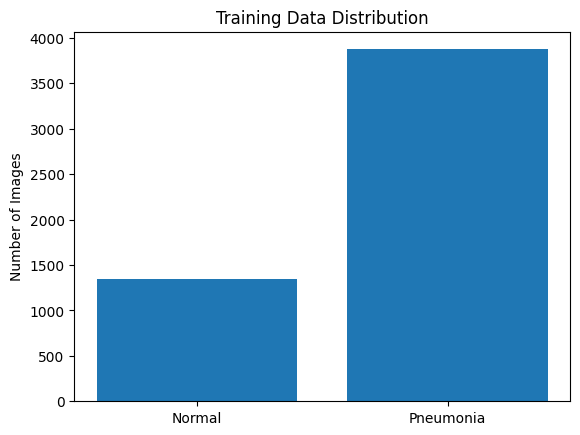

In [6]:
labels = ["Normal", "Pneumonia"]
train_counts = [train_normal, train_pneu]

plt.figure()
plt.bar(labels, train_counts)
plt.title("Training Data Distribution")
plt.ylabel("Number of Images")
plt.show()

Exploratory analysis of the dataset reveals an uneven distribution between the two classes in the training data. The number of pneumonia images is substantially higher than the number of normal images. Such class imbalance can influence the behaviour of machine learning models, as the classifier may become biased toward predicting the majority class. Therefore, visualising the distribution of the classes is useful for understanding the dataset characteristics and for planning potential strategies such as class weighting or data augmentation during model training. Additionally, analysing the pixel intensity distribution of the images helps understand the range of pixel values present in the X-ray images and supports the decision to apply normalization during preprocessing.

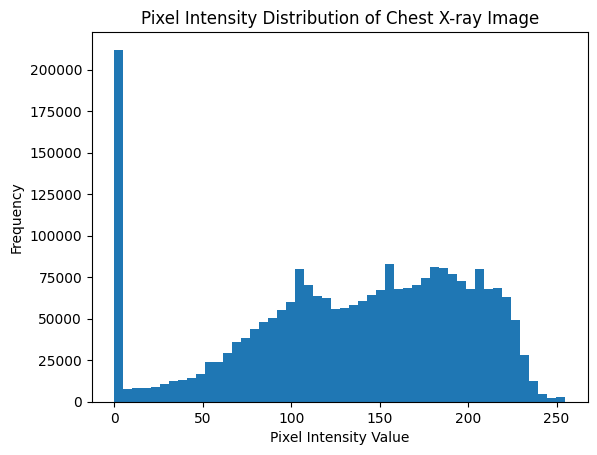

In [9]:
img_path = os.path.join(train_path, "NORMAL", normal_images[0])
img = Image.open(img_path)

img_array = np.array(img)

plt.figure()
plt.hist(img_array.flatten(), bins=50)
plt.title("Pixel Intensity Distribution of Chest X-ray Image")
plt.xlabel("Pixel Intensity Value")
plt.ylabel("Frequency")
plt.show()

The histogram illustrates the distribution of pixel intensity values in a sample chest X-ray image. The pixel values span a wide range between 0 and 255, which is typical for grayscale medical images. This variation in intensity reflects different levels of tissue density captured in the X-ray scan. Since neural networks generally perform better when input values are within a consistent numerical range, these pixel values will be normalised (for example, scaled to the range 0–1) during preprocessing. Normalisation helps stabilise the training process, improves convergence of the optimisation algorithm, and allows the CNN to learn meaningful visual patterns more effectively.

## **visual comparison of healthy vs infected lungs.**

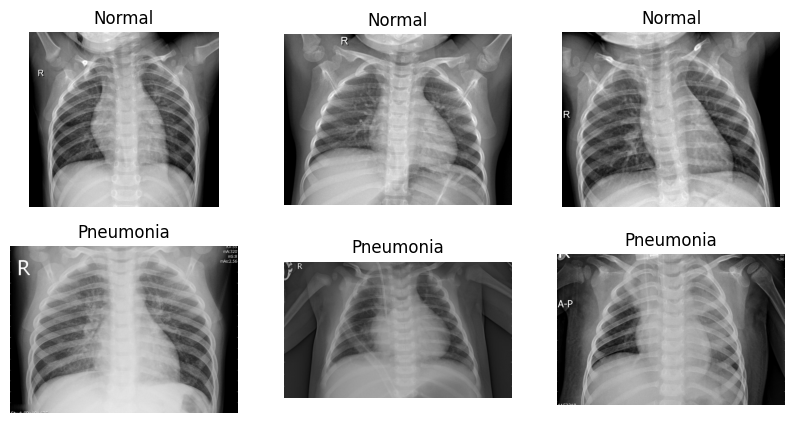

In [7]:
import random

normal_images = os.listdir(os.path.join(train_path, "NORMAL"))
pneumonia_images = os.listdir(os.path.join(train_path, "PNEUMONIA"))

plt.figure(figsize=(10,5))

for i in range(3):

    img_path = os.path.join(train_path, "NORMAL", random.choice(normal_images))
    img = Image.open(img_path)

    plt.subplot(2,3,i+1)
    plt.imshow(img, cmap="gray")
    plt.title("Normal")
    plt.axis("off")

for i in range(3):

    img_path = os.path.join(train_path, "PNEUMONIA", random.choice(pneumonia_images))
    img = Image.open(img_path)

    plt.subplot(2,3,i+4)
    plt.imshow(img, cmap="gray")
    plt.title("Pneumonia")
    plt.axis("off")

plt.show()

## **Check image size**

In [8]:
sizes = []

sample_images = normal_images[:50]

for img_name in sample_images:
    img_path = os.path.join(train_path, "NORMAL", img_name)
    img = Image.open(img_path)
    sizes.append(img.size)

print("Example image sizes:", sizes[:10])

Example image sizes: [(1828, 1357), (2080, 1781), (1410, 1179), (1742, 1322), (1226, 955), (1858, 1380), (1404, 1059), (1790, 1132), (1550, 1059), (1484, 1267)]


# **Data preprocessing**

In [10]:
import tensorflow as tf
from tensorflow import keras

In [11]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


In [12]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

In [15]:
class_names = ['NORMAL', 'PNEUMONIA']
print(class_names)

['NORMAL', 'PNEUMONIA']


In [16]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("First 10 labels:", labels[:10].numpy())

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32, 1)
First 10 labels: [[1.]
 [0.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]]


The preprocessing stage involved preparing the chest X-ray images for input into the convolutional neural network. The images were loaded using a directory-based dataset loader, which automatically assigned labels based on folder names. Since the original images had varying resolutions, all images were resized to a fixed dimension of 224×224 pixels. Pixel intensity values were then normalized from the range 0–255 to 0–1 to improve training stability. The dataset was organized into batches of 32 images to enhance computational efficiency during model training. Finally, the dataset pipeline was verified by inspecting batch shapes and labels to ensure correct data formatting.

## **Normalization**

In [17]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

## **Data Augmentation**

In [18]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)
])

To improve training stability, pixel values were normalized from the range 0–255 to 0–1 using a rescaling layer. Normalization ensures that the neural network receives inputs within a consistent numerical range, which helps accelerate convergence during optimisation. In addition, data augmentation techniques such as small rotations, zooming, and contrast adjustments may be applied to the training images.